# Layer 1 quality metrics EDA

Explore station-day metric vectors and rule incident rates. Requires gold output from:

```bash
python -m pipelines quality
```

In [2]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from pipelines.quality.build import read_quality_incidents, read_quality_metrics

GOLD_ROOT = ROOT / "data" / "gold"
metrics = read_quality_metrics(GOLD_ROOT)
incidents = read_quality_incidents(GOLD_ROOT)
print(f"Station-days: {len(metrics)}")
print(f"Incidents: {len(incidents)}")
metrics.head()

Station-days: 8
Incidents: 9


,locationid,date_local,total_readings,missing_rate_mean,sensors_expected,sensors_received,sensor_dropout_count,negative_count_total,max_stuck_run_max,zero_variance_params,duplicate_rate,schema_changed,file_present,file_lateness_hours,unit_mismatch_count,cross_sensor_pm25_spread
0,1544061,2026-01-01,115,0.041667,5,5,0,0,1,0,0.0,False,True,0.0,0,0.0
1,1544061,2026-01-02,5,0.956522,5,5,0,0,1,5,0.0,False,False,0.0,0,0.0
2,1601414,2026-01-01,69,0.041667,3,3,0,0,1,0,0.0,False,True,0.0,0,0.0
3,1601414,2026-01-02,3,0.956522,3,3,0,0,1,3,0.0,False,False,0.0,0,0.0
4,2455394,2026-01-01,115,0.041667,5,5,0,0,1,0,0.0,False,True,0.0,0,0.0


## Metric distributions

In [3]:
if metrics.empty:
    print("No metrics yet — run python -m pipelines quality")
else:
    cols = ["missing_rate_mean", "max_stuck_run_max", "duplicate_rate", "negative_count_total"]
    metrics[cols].describe()

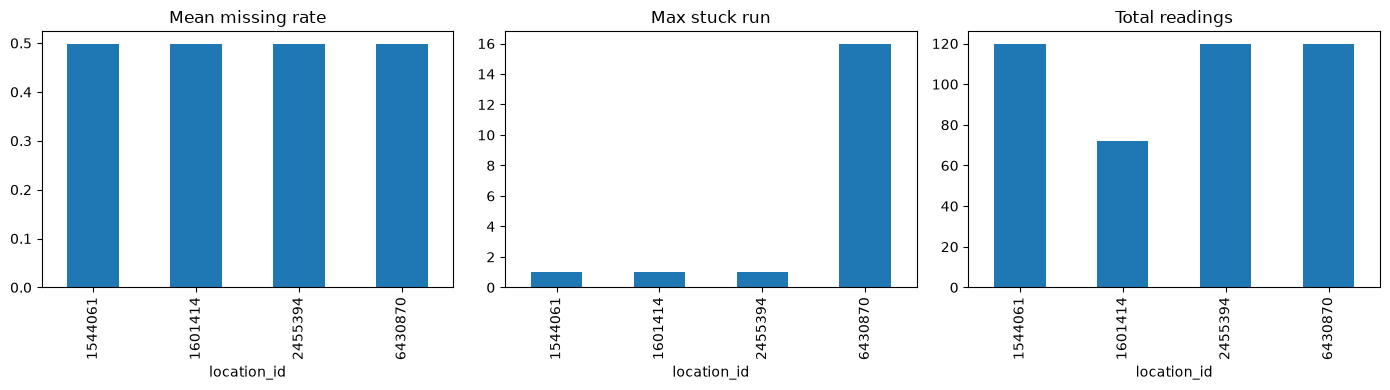

In [4]:
if not metrics.empty:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    metrics.groupby("locationid")["missing_rate_mean"].mean().plot.bar(ax=axes[0], title="Mean missing rate")
    metrics.groupby("locationid")["max_stuck_run_max"].max().plot.bar(ax=axes[1], title="Max stuck run")
    metrics.groupby("locationid")["total_readings"].sum().plot.bar(ax=axes[2], title="Total readings")
    plt.tight_layout()
    plt.show()

## Rule fire rates

In [5]:
if incidents.empty:
    print("No incidents flagged")
else:
    counts = incidents.groupby(["rule_id", "incident_type"]).size().reset_index(name="count")
    display(counts.sort_values("count", ascending=False))
    incidents[["locationid", "date_local", "rule_id", "severity", "event_code"]].head(20)

,rule_id,incident_type,count
1,R4,completeness_gap,4
2,R7,missing_file,4
0,R2,stuck_sensor,1


## Completeness heatmap (location x date)

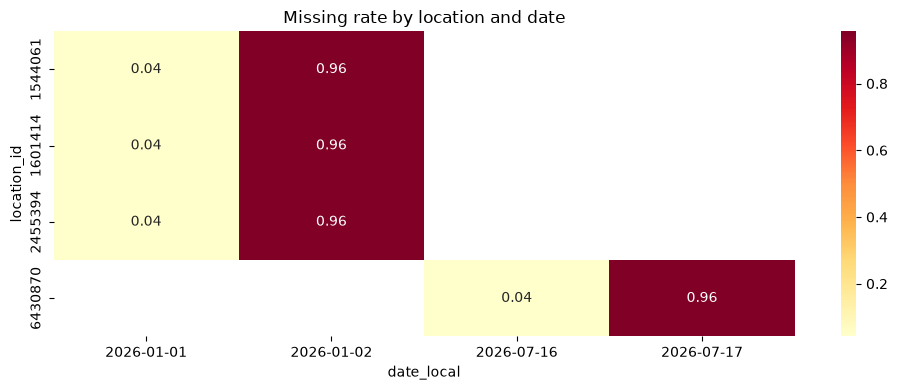

In [6]:
if not metrics.empty:
    pivot = metrics.pivot(index="locationid", columns="date_local", values="missing_rate_mean")
    plt.figure(figsize=(10, 4))
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlOrRd")
    plt.title("Missing rate by location and date")
    plt.tight_layout()
    plt.show()

## Stuck-run threshold sensitivity

In [7]:
if not metrics.empty:
    thresholds = [4, 6, 8, 12]
    rows = []
    for t in thresholds:
        flagged = (metrics["max_stuck_run_max"] >= t).sum()
        rows.append({"threshold": t, "station_days_flagged": int(flagged)})
    pd.DataFrame(rows)

## Feature correlation (Isolation Forest input)

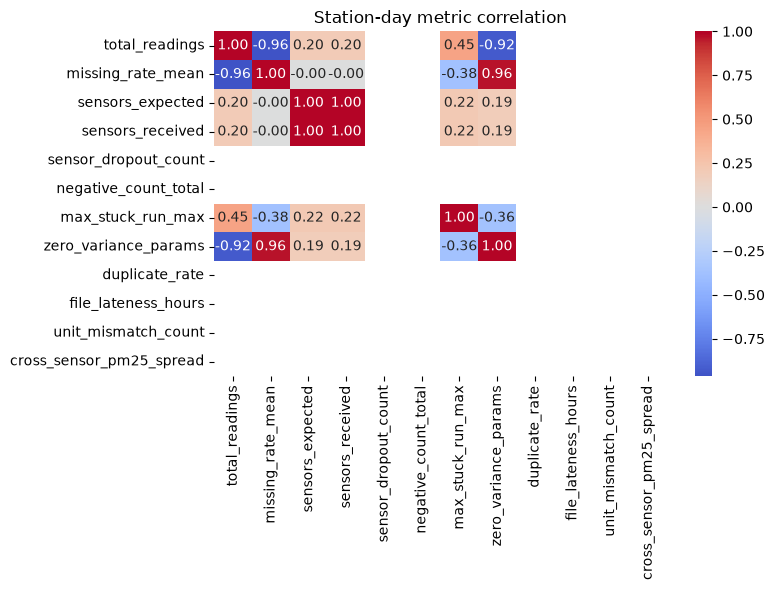

In [8]:
from pipelines.quality.metrics import METRIC_COLUMNS

if not metrics.empty and len(metrics) > 1:
    corr = metrics[METRIC_COLUMNS].corr()
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
    plt.title("Station-day metric correlation")
    plt.tight_layout()
    plt.show()